In [43]:
from nonthradsim.grid import *
from nonthradsim.particle import *
from nonthradsim.spectrum import *
from nonthradsim.synchrotron import *
import nonthradsim.Constants as C

def MaxwellBoltzmann(spectrum, T, n):
    # TODO: Implement the Maxwell-Boltzmann distribution for the particle spectrum
    spectrum.spec = np.sqrt(spectrum.E)*np.exp(-(spectrum.E) * C.me * C.c**2 / T)
    spectrum.set_norm(n)
    return

def Powerlaw(spectrum, alpha, Emin, Emax, n):
    # TODO: Implement the power-law distribution for the particle spectrum
    spectrum.spec = np.where((spectrum.E >= Emin) & (spectrum.E <= Emax), spectrum.E ** (-alpha), 0)
    spectrum.set_norm(n)
    return

if __name__ == "__main__":
    T = 1e3
    grid = Grid(dimension=3, dx=0.1, n_mesh=21, data_type=float)
    particle = Particle(grid = grid,
                        mass=C.me,
                        charge=-C.q,
                        gm_min=1e3,
                        gm_max=1e10,
                        n_spectrum=101)
    
    for idx in np.ndindex(particle.value.shape):
        # MaxwellBoltzmann(particle.value[idx], T, 1e16)
        Powerlaw(particle.value[idx], alpha=4.0, Emin=1e0, Emax=1e7, n=1e16)
    print("Particle values initialized.")

    photon = Photon(grid = grid,
                    Emin=1e-20,
                    Emax=1e0,
                    n_spectrum=101)
    

    B = 1e-1
    # prepare Function Table
    Fx = F()
    for idx in np.ndindex(particle.value.shape):
        synchrotron(photon.value[idx], particle.value[idx], B, Fx)
        # print(idx)
    
    print("Photon values initialized.")

    


Particle values initialized.
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.7322073965737737e-16
1.732

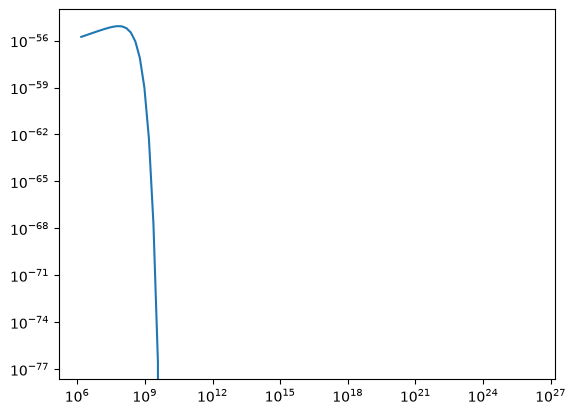

In [44]:
plt.loglog(photon[0,0,0].E / C.h, photon[0,0,0].E**2* photon[0,0,0].spec)
# print(photon[0,0,0].spec)
# plt.loglog(particle[0,0,0].E * C.me * C.c**2, particle[0,0,0].spec)

In [45]:
1/4 * B / (C.me * C.c) * 1e20

9.154408950003031e+34